# 07 — Training a Language Model from Scratch

## Goal

The previous lessons studied the major pieces of language-model
training separately:

- tokenization,
- sequence construction and batching,
- embeddings and linear layers,
- cross-entropy loss,
- automatic differentiation,
- optimization.

This lesson connects those pieces into a complete training loop.

We will deliberately begin with a very small language model that does
not use attention.

The model predicts the next token using only the current token.

This gives us a controlled environment for understanding:

- model parameters,
- forward computation,
- training and validation loss,
- gradient computation,
- optimizer updates,
- learning-rate scheduling,
- evaluation,
- and autoregressive sampling.

The goal is to understand the complete training process before adding
context-dependent mechanisms such as self-attention.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

## 1. A Context-Free Baseline

Our first trainable language model will predict the next token using
only the current token:

$$
p(x_{t+1}\mid x_t).
$$

It cannot yet use the full context

$$
x_1,\ldots,x_t.
$$

This limitation is intentional.

The model provides a simple baseline in which the full training pipeline
can be studied without the additional complexity of attention.

Later, self-attention will change the representation of each token so
that its prediction can depend on previous tokens.

## 2. Model Architecture

Let

$$
V
$$

be the vocabulary size and

$$
C
$$

the embedding dimension.

The model contains an embedding table

$$
E\in\mathbb{R}^{V\times C}
$$

and a language-model projection

$$
W\in\mathbb{R}^{C\times V}.
$$

For token IDs

$$
X\in\mathbb{N}^{B\times T},
$$

embedding lookup gives

$$
H = E[X]
\in
\mathbb{R}^{B\times T\times C}.
$$

The output projection then produces

$$
Z = HW+b
\in
\mathbb{R}^{B\times T\times V}.
$$

Each position therefore produces one logit for every vocabulary token.

Because no operation mixes different sequence positions, the prediction
at position $t$ depends only on token $x_t$.

In [11]:
text: str = (
    "hello world\n"
    "hello language model\n"
    "hello world\n"
    "language models predict tokens\n"
) * 50

In [12]:
# character tokenizer

vocab: list[str] = sorted(set(text))

token_to_id: dict[str, int] = {
    token: index for index, token in enumerate(vocab)
}

id_to_token: dict[int, str] = {
    index: token for index, token in enumerate(vocab)
}


def encode(text: str) -> list[int]:
    return [token_to_id[token] for token in text]


def decode(token_ids: list[int]) -> str:
    return "".join(id_to_token[token_id] for token_id in token_ids)


token_ids: list[int] = encode(text)

vocab_size: int = len(vocab)

print("characters:", len(text))
print("tokens:", len(token_ids))
print("vocabulary size:", vocab_size)

characters: 3800
tokens: 3800
vocabulary size: 20


In [13]:
# train/val split
split_index: int = int(0.9 * len(token_ids))

train_tokens: list[int] = token_ids[:split_index]
validation_tokens: list[int] = token_ids[split_index:]

print(len(train_tokens))
print(len(validation_tokens))

3420
380


In [ ]:
# batch
def get_batch(
    tokens: list[int],
    batch_size: int,
    context_length: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    max_start: int = len(tokens) - context_length

    starts: torch.Tensor = torch.randint(
        low=0,
        high=max_start,
        size=(batch_size,),
    )

    inputs: list[list[int]] = []
    targets: list[list[int]] = []

    for start_tensor in starts:
        start: int = int(start_tensor.item())

        inputs.append(tokens[start : start + context_length])

        targets.append(tokens[start + 1 : start + context_length + 1])

    return (
        torch.tensor(
            inputs,
            dtype=torch.long,
        ),
        torch.tensor(
            targets,
            dtype=torch.long,
        ),
    )

## Bigram Language Model

We now combine previously studied components into a trainable language
model.

This notebook does not reimplement embeddings, linear layers,
cross-entropy, or AdamW. Those mechanisms were studied separately in
earlier lessons.

Instead, we use the corresponding PyTorch implementations and focus on
the structure of a complete training process.

Our baseline model predicts

$$
p(x_{t+1}\mid x_t).
$$

The model therefore uses only the current token and does not yet mix
information across sequence positions.

Its computation is:

<pre>
token IDs
    ↓
embedding lookup
    ↓
token representations
    ↓
linear vocabulary projection
    ↓
next-token logits
</pre>

For an input batch

$$
X\in\mathbb{N}^{B\times T},
$$

the embedding layer produces

$$
H\in\mathbb{R}^{B\times T\times C},
$$

and the language-model head produces

$$
Z\in\mathbb{R}^{B\times T\times V}.
$$

In [15]:
# Bigram model


class BigramLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
    ) -> None:
        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
        )

        self.lm_head = nn.Linear(
            embedding_dim,
            vocab_size,
        )

    def forward(
        self,
        token_ids: torch.Tensor,
    ) -> torch.Tensor:
        embeddings: torch.Tensor = self.token_embedding(token_ids)

        logits: torch.Tensor = self.lm_head(embeddings)

        return logits


embedding_dim: int = 16

model = BigramLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
)

x, y = get_batch(
    train_tokens,
    batch_size=4,
    context_length=8,
)

logits: torch.Tensor = model(x)

print("x:", x.shape)
print("targets:", y.shape)
print("logits:", logits.shape)

x: torch.Size([4, 8])
targets: torch.Size([4, 8])
logits: torch.Size([4, 8, 20])


### Why `nn.Module`?

Earlier lessons implemented individual mathematical components
explicitly.

At the model level, we now use `torch.nn.Module` to organize trainable
components.

A module provides infrastructure for:

- registering trainable parameters,
- organizing nested submodules,
- moving the model between devices,
- switching between training and evaluation modes,
- saving and loading model state.

The mathematical computation is still defined explicitly in
`forward()`.

Using `nn.Module` therefore changes how the components are organized,
not the model equation itself.

In [17]:
embedding_dim: int = 32

model = BigramLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
)

logits: torch.Tensor = model(x)

print("inputs:", x.shape)
print("targets:", x.shape)
print("logits:", logits.shape)

inputs: torch.Size([4, 8])
targets: torch.Size([4, 8])
logits: torch.Size([4, 8, 20])


### Training Loss

Cross-entropy was derived and implemented from scratch in the previous
lesson.

From this point onward, we use PyTorch's optimized implementation.

The language model produces logits of shape

$$
(B,T,V),
$$

while the targets have shape

$$
(B,T).
$$

For the loss interface, the batch and time positions are treated as
$BT$ prediction examples:

$$
(B,T,V)\rightarrow(BT,V)
$$

and

$$
(B,T)\rightarrow(BT).
$$

In [18]:
batch_size, context_length, vocab_size = logits.shape
loss: torch.Tensor = F.cross_entropy(
    logits.reshape(-1, vocab_size),
    y.reshape(-1),
)

In [19]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-3,
    weight_decay=0.01,
)

for name, parameter in model.named_parameters():
    print(
        name,
        tuple(parameter.shape),
        parameter.numel(),
    )

token_embedding.weight (20, 32) 640
lm_head.weight (20, 32) 640
lm_head.bias (20,) 20


## A Single Training Step

A training step performs four conceptually distinct operations:

<pre>
1. forward
2. loss computation
3. backward
4. parameter update
</pre>

The optimizer does not compute the gradients.

Autograd does not update the parameters.

Keeping these responsibilities separate makes the training process
easier to reason about.

In [20]:
def train_step(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    inputs: torch.Tensor,
    targets: torch.Tensor,
) -> float:
    model.train()
    optimizer.zero_grad()
    logits: torch.Tensor = model(inputs)

    vocab_size: int = logits.shape[-1]

    loss: torch.Tensor = F.cross_entropy(
        logits.reshape(-1, vocab_size), targets.reshape(-1)
    )

    loss.backward()
    optimizer.step()

    return loss.item()


batch_size: int = 32
context_length: int = 16
num_steps: int = 1000


for step in range(1, num_steps + 1):
    inputs, targets = get_batch(
        train_tokens,
        batch_size=batch_size,
        context_length=context_length,
    )

    loss: float = train_step(
        model=model,
        optimizer=optimizer,
        inputs=inputs,
        targets=targets,
    )

    if step % 100 == 0:
        print(f"step={step:4d} train_loss={loss:.4f}")

step= 100 train_loss=1.0925
step= 200 train_loss=0.9493
step= 300 train_loss=0.9646
step= 400 train_loss=0.9669
step= 500 train_loss=0.9511
step= 600 train_loss=0.9788
step= 700 train_loss=0.9427
step= 800 train_loss=0.9473
step= 900 train_loss=0.9539
step=1000 train_loss=0.9712


## Estimating Training and Validation Loss

The loss from a single training batch is a noisy measurement.

Different randomly sampled batches may contain sequences of different
difficulty, so the reported loss can fluctuate even when the model is
improving.

To obtain a more stable estimate, we evaluate the model on several
batches and compute the mean loss.

We estimate loss separately for:

- the training split,
- the validation split.

The training loss measures how well the model fits data used for
optimization.

The validation loss measures how well the learned parameters generalize
to held-out data.

During loss estimation, model parameters must not be updated.

In [21]:
@torch.no_grad()
def estimate_loss(
    model: nn.Module,
    train_tokens: list[int],
    validation_tokens: list[int],
    batch_size: int,
    context_length: int,
    evaluation_batches: int,
) -> dict[str, float]:
    model.eval()
    results: dict[str, float] = {}
    splits: dict[str, list[int]] = {
        "train": train_tokens,
        "validation": validation_tokens,
    }

    for split_name, tokens in splits.items():
        losses: list[float] = []

        for _ in range(evaluation_batches):
            inputs, targets = get_batch(
                tokens=tokens,
                batch_size=batch_size,
                context_length=context_length,
            )
            logits: torch.Tensor = model(inputs)

            vocab_size: int = logits.shape[-1]

            loss: torch.Tensor = F.cross_entropy(
                logits.reshape(-1, vocab_size), targets.reshape(-1)
            )

            losses.append(loss.item())

        results[split_name] = sum(losses) / len(losses)

    model.train()

    return results


In [22]:
for step in range(1, num_steps + 1):
    inputs, targets = get_batch(
        train_tokens,
        batch_size=batch_size,
        context_length=context_length,
    )

    train_loss: float = train_step(
        model=model,
        optimizer=optimizer,
        inputs=inputs,
        targets=targets,
    )

    if step % 100 == 0:
        losses = estimate_loss(
            model=model,
            train_tokens=train_tokens,
            validation_tokens=validation_tokens,
            batch_size=batch_size,
            context_length=context_length,
            evaluation_batches=20,
        )

        print(
            f"step={step:4d} "
            f"train={losses['train']:.4f} "
            f"val={losses['validation']:.4f}"
        )

step= 100 train=0.9492 val=0.9521
step= 200 train=0.9528 val=0.9579
step= 300 train=0.9583 val=0.9567
step= 400 train=0.9489 val=0.9492
step= 500 train=0.9525 val=0.9586
step= 600 train=0.9482 val=0.9562
step= 700 train=0.9569 val=0.9517
step= 800 train=0.9499 val=0.9522
step= 900 train=0.9461 val=0.9543
step=1000 train=0.9522 val=0.9475


### `train()` vs `eval()`

`model.eval()` is equivalent to `model.train(False)`.

It recursively sets the `training` flag of the model and its registered
submodules to `False`.

Some modules change their forward behavior based on this flag:

- Dropout becomes inactive.
- BatchNorm uses stored running statistics instead of batch statistics.

Other modules such as `Linear`, `Embedding`, and `LayerNorm` behave the
same in both modes.

Importantly:

`model.eval()` does **not** disable autograd, freeze parameters, or stop
the optimizer from updating them.

Evaluation commonly uses both:

<pre>
model.eval()
+
torch.no_grad()
</pre>

because they solve different problems:

<pre>
eval()      → changes module behavior
no_grad()   → disables gradient tracking

## Autoregressive Generation

Training and generation use the same next-token prediction model in
different ways.

During training, the complete target sequence is already known.

During generation, only the tokens generated so far are available.

At each step, we:

1. pass the current token sequence through the model,
2. take the logits for the final position,
3. convert those logits into a probability distribution,
4. sample one next-token ID,
5. append the sampled token to the sequence,
6. repeat.

This creates an autoregressive process:

$$
x_1
\rightarrow
x_2
\rightarrow
x_3
\rightarrow
\cdots
$$

More generally,

$$
x_{t+1}
\sim
p(x_{t+1}\mid x_{\leq t}).
$$

Our current bigram model is more limited:

$$
p(x_{t+1}\mid x_t),
$$

because it does not yet mix information across token positions.

In [23]:
prompt: str = "h"

input_ids: torch.Tensor = torch.tensor(
    [[token_to_id[char] for char in prompt]],
    dtype=torch.long,
)

print(input_ids)
print(input_ids.shape)

tensor([[7]])
torch.Size([1, 1])


In [24]:
model.eval()

with torch.no_grad():
    logits: torch.Tensor = model(input_ids)

print(logits.shape)

torch.Size([1, 1, 20])


In [25]:
next_token_logits: torch.Tensor = logits[:, -1, :]

print(next_token_logits.shape)

torch.Size([1, 20])


In [26]:
probabilities: torch.Tensor = torch.softmax(
    next_token_logits,
    dim=-1,
)

print(probabilities.shape)
print(probabilities.sum(dim=-1))

torch.Size([1, 20])
tensor([1.0000])


In [27]:
# greedy decoding
next_token_id: torch.Tensor = torch.argmax(
    probabilities,
    dim=-1,
    keepdim=True,
)

print(next_token_id)
print(next_token_id.shape)

tensor([[5]])
torch.Size([1, 1])


In [28]:
input_ids = torch.cat(
    [input_ids, next_token_id],
    dim=1,
)

print(input_ids)
print(input_ids.shape)

tensor([[7, 5]])
torch.Size([1, 2])


In [30]:
# probability distribution sampling
next_token_id = torch.multinomial(
    probabilities,
    num_samples=1,
)
print(next_token_id)
print(next_token_id.shape)

tensor([[5]])
torch.Size([1, 1])


In [34]:
# Generate func


@torch.no_grad()
def generate(
    model: nn.Module, input_ids: torch.Tensor, max_new_tokens: int
) -> torch.Tensor:
    model.eval()

    generated: torch.Tensor = input_ids

    for _ in range(max_new_tokens):
        logits: torch.Tensor = model(input_ids)
        next_token_logits: torch.Tensor = logits[:, -1, :]

        probabilities: torch.Tensor = torch.softmax(next_token_logits, dim=-1)

        next_token_id: torch.Tensor = torch.multinomial(
            probabilities, num_samples=1
        )

        generated = torch.cat([generated, next_token_id], dim=-1)

    return generated


In [35]:
prompt: str = "h"

prompt_ids: torch.Tensor = torch.tensor(
    [[token_to_id[char] for char in prompt]],
    dtype=torch.long,
)

generated_ids: torch.Tensor = generate(
    model=model,
    input_ids=prompt_ids,
    max_new_tokens=100,
)

generated_text: str = decode(generated_ids[0].tolist())

print(generated_text)


heeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee


In [36]:
context_a: torch.Tensor = torch.tensor(
    [[1, 2, 3]],
    dtype=torch.long,
)

context_b: torch.Tensor = torch.tensor(
    [[5, 9, 3]],
    dtype=torch.long,
)

with torch.no_grad():
    logits_a = model(context_a)[:, -1, :]
    logits_b = model(context_b)[:, -1, :]

print(
    torch.allclose(
        logits_a,
        logits_b,
    )
)

True


### Training vs Generation

During training, many next-token predictions are evaluated in parallel.

For a batch with shape

$$
(B,T),
$$

the model produces

$$
BT
$$

next-token predictions in one forward pass.

Generation is fundamentally sequential.

The token generated at step $t$ becomes part of the input needed to
generate token $t+1$.

Therefore:

<pre>
training
    → many known targets can be processed in parallel

generation
    → future tokens do not exist yet and must be produced sequentially
</pre>

This sequential dependency is one of the fundamental computational
differences between language-model training and autoregressive
inference.

## 8. Putting the Training Loop Together

We now have all components required for a complete language-model
training process.

Each optimization step performs:

<pre>
sample training batch
        ↓
forward pass
        ↓
cross-entropy loss
        ↓
backward pass
        ↓
optimizer update
</pre>

At regular intervals, we temporarily stop parameter updates and estimate
the mean training and validation losses over multiple batches.

This gives us two different kinds of measurements:

- the loss of the current training batch,
- a more stable estimate of train and validation performance.

Only the first one participates in optimization.

In [37]:
initial_losses: dict[str, float] = estimate_loss(
    model=model,
    train_tokens=train_tokens,
    validation_tokens=validation_tokens,
    batch_size=32,
    context_length=16,
    evaluation_batches=20,
)

print(initial_losses)

{'train': 0.9543923676013947, 'validation': 0.9440530508756637}


In [39]:
import math

print("uniform baseline:", math.log(vocab_size))

uniform baseline: 2.995732273553991


In [40]:
prompt: str = "h"

prompt_ids: torch.Tensor = torch.tensor(
    [[token_to_id[char] for char in prompt]],
    dtype=torch.long,
)

generated_before: torch.Tensor = generate(
    model=model,
    input_ids=prompt_ids,
    max_new_tokens=100,
)

print(
    "before training:",
    repr(decode(generated_before[0].tolist())),
)

before training: 'heeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee'


In [41]:
steps_history: list[int] = []
train_loss_history: list[float] = []
validation_loss_history: list[float] = []

In [42]:
num_steps: int = 1_000
batch_size: int = 32
context_length: int = 16
evaluation_interval: int = 100
evaluation_batches: int = 20

In [43]:
for step in range(1, num_steps + 1):
    inputs, targets = get_batch(
        tokens=train_tokens,
        batch_size=batch_size,
        context_length=context_length,
    )

    train_step(
        model=model,
        optimizer=optimizer,
        inputs=inputs,
        targets=targets,
    )

    if step == 1 or step % evaluation_interval == 0:
        losses: dict[str, float] = estimate_loss(
            model=model,
            train_tokens=train_tokens,
            validation_tokens=validation_tokens,
            batch_size=batch_size,
            context_length=context_length,
            evaluation_batches=evaluation_batches,
        )

        steps_history.append(step)
        train_loss_history.append(losses["train"])
        validation_loss_history.append(losses["validation"])

        print(
            f"step={step:4d} "
            f"train={losses['train']:.4f} "
            f"val={losses['validation']:.4f}"
        )

step=   1 train=0.9497 val=0.9413
step= 100 train=0.9543 val=0.9485
step= 200 train=0.9587 val=0.9542
step= 300 train=0.9452 val=0.9566
step= 400 train=0.9481 val=0.9462
step= 500 train=0.9518 val=0.9469
step= 600 train=0.9513 val=0.9485
step= 700 train=0.9483 val=0.9452
step= 800 train=0.9466 val=0.9392
step= 900 train=0.9502 val=0.9565
step=1000 train=0.9534 val=0.9440


### Monitoring Training

A single scalar loss value does not show the trajectory of optimization.

Recording periodic train and validation estimates allows us to inspect
how learning evolves over time.

Typical patterns include:

<pre>
train ↓   validation ↓
    → learning useful structure

train ↓   validation ↑
    → possible overfitting

train flat   validation flat
    → optimization may not be progressing
</pre>

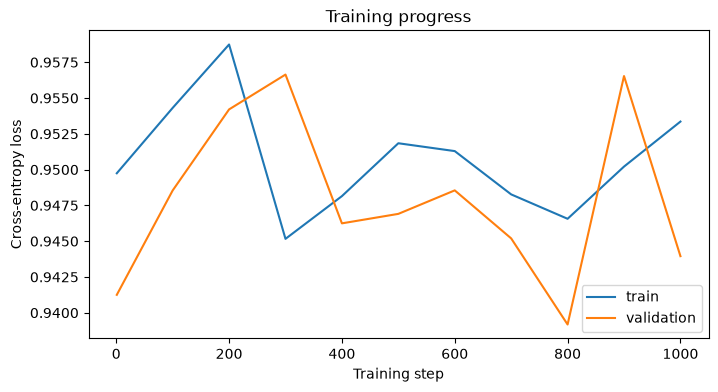

In [44]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 4))

plt.plot(
    steps_history,
    train_loss_history,
    label="train",
)

plt.plot(
    steps_history,
    validation_loss_history,
    label="validation",
)

plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Training progress")
plt.legend()

plt.show()

In [45]:
generated_after: torch.Tensor = generate(
    model=model,
    input_ids=prompt_ids,
    max_new_tokens=100,
)

print(
    "after training:",
    repr(decode(generated_after[0].tolist())),
)

after training: 'heeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee'


In [46]:
context_a: torch.Tensor = torch.tensor(
    [
        [
            token_to_id["h"],
            token_to_id["e"],
            token_to_id["l"],
        ]
    ],
    dtype=torch.long,
)

context_b: torch.Tensor = torch.tensor(
    [
        [
            token_to_id["d"],
            token_to_id["e"],
            token_to_id["l"],
        ]
    ],
    dtype=torch.long,
)

model.eval()

with torch.no_grad():
    logits_a: torch.Tensor = model(context_a)[:, -1, :]

    logits_b: torch.Tensor = model(context_b)[:, -1, :]

print(
    torch.allclose(
        logits_a,
        logits_b,
    )
)

True


### What This Experiment Demonstrates

The purpose of this experiment is not to build a capable language
model.

It verifies that the complete training pipeline works:

<pre>
text
 ↓
token IDs
 ↓
batches
 ↓
model
 ↓
logits
 ↓
cross-entropy
 ↓
gradients
 ↓
optimizer
 ↓
updated parameters
 ↓
generation
</pre>

The model remains fundamentally limited because each prediction depends
only on the current token.

This limitation motivates the next architectural step: mechanisms that
allow information to flow between token positions.

## 9. Gradient Clipping

After backpropagation, every trainable parameter may contain a gradient.

If some gradients become unusually large, a single optimizer step can
produce an excessively large parameter update.

A common stabilization technique is **global gradient-norm clipping**.

Suppose the model contains gradients

$$
g_1, g_2, \ldots, g_n.
$$

We treat all gradient values as if they belonged to one large vector
and compute the global L2 norm:

$$
\|g\|_2
=
\sqrt{
\sum_i \|g_i\|_2^2
}.
$$

Given a maximum allowed norm

$$
G_{\max},
$$

we keep the gradients unchanged when

$$
\|g\|_2 \leq G_{\max}.
$$

If

$$
\|g\|_2 > G_{\max},
$$

all gradients are multiplied by the same factor

$$
s
=
\frac{G_{\max}}
{\|g\|_2}.
$$

Therefore,

$$
g_i
\leftarrow
s g_i.
$$

The direction of the complete gradient vector is preserved; only its
magnitude is reduced.

In [48]:
def global_grad_norm(parameters: list[torch.Tensor]) -> torch.Tensor:
    squard_norms: list[torch.Tensor] = []

    for parameter in parameters:
        if parameter.grad is None:
            continue

        squard_norms.append(parameter.grad.square().sum())

    if not squard_norms:
        return torch.tensor(0.0)

    total_squard_norm: torch.Tensor = torch.stack(squard_norms).sum()

    return torch.sqrt(total_squard_norm)

In [49]:
def clip_grad_norm(
    parameters: list[torch.Tensor], max_norm: float, epsilon: float = 1e-12
) -> float:
    if max_norm <= 0.0:
        raise ValueError("max_norm must be positive")

    norm: torch.Tensor = global_grad_norm(parameters)

    norm_value: float = norm.item()

    if norm_value <= max_norm:
        return norm_value

    scale: float = max_norm / (norm_value + epsilon)

    with torch.no_grad():
        for parameter in parameters:
            if parameter.grad is None:
                continue

            parameter.grad.mul_(scale)

    return norm_value

In [50]:
a: torch.Tensor = torch.tensor(
    [1.0, 2.0],
    requires_grad=True,
)

b: torch.Tensor = torch.tensor(
    [3.0, 4.0],
    requires_grad=True,
)

a.grad = torch.tensor([3.0, 4.0])
b.grad = torch.tensor([0.0, 12.0])

parameters: list[torch.Tensor] = [a, b]

print(
    "before:",
    global_grad_norm(parameters).item(),
)

original_norm: float = clip_grad_norm(
    parameters,
    max_norm=6.5,
)

print("original norm:", original_norm)
print(
    "after:",
    global_grad_norm(parameters).item(),
)

print("a.grad:", a.grad)
print("b.grad:", b.grad)

before: 13.0
original norm: 13.0
after: 6.5
a.grad: tensor([1.5000, 2.0000])
b.grad: tensor([0., 6.])


In [51]:
def train_step(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    inputs: torch.Tensor,
    targets: torch.Tensor,
    max_grad_norm: float | None = None,
) -> tuple[float, float | None]:
    model.train()
    optimizer.zero_grad()

    logits: torch.Tensor = model(inputs)

    vocab_size: int = logits.shape[-1]

    loss: torch.Tensor = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1),
    )

    loss.backward()

    grad_norm: float | None = None

    if max_grad_norm is not None:
        grad_norm = clip_grad_norm(
            list(model.parameters()),
            max_norm=max_grad_norm,
        )

    optimizer.step()

    return loss.item(), grad_norm

## 10. Checkpointing

Training changes several pieces of state over time.

The most obvious state is the model itself:

$$
\theta_t.
$$

However, resuming training may require more than model parameters.

For AdamW, the optimizer also contains persistent state such as:

- first moments,
- second moments,
- optimizer step counters.

The training process may additionally depend on:

- the current global step,
- learning-rate schedule position,
- model configuration,
- tokenizer or vocabulary information.

A checkpoint is a snapshot of the state required to continue or reuse a
trained model.

Two use cases should be distinguished:

<pre>
inference checkpoint
    → enough information to run the trained model

training checkpoint
    → enough information to continue optimization
</pre>

In [ ]:
checkpoint: dict[str, object] = {
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "step": current_step,
    "vocab": vocab,
    "embedding_dim": embedding_dim,
}

torch.save(
    checkpoint,
    "checkpoints/bigram_checkpoint.pt",
)

In [ ]:
checkpoint = torch.load(
    "checkpoints/bigram_checkpoint.pt",
    weights_only=False,
)

In [ ]:
restored_model = BigramLanguageModel(
    vocab_size=len(checkpoint["vocab"]),
    embedding_dim=checkpoint["embedding_dim"],
)

In [ ]:
restored_optimizer = torch.optim.AdamW(
    restored_model.parameters(),
    lr=3e-3,
    weight_decay=0.01,
)

In [ ]:
restored_step: int = checkpoint["step"]

## Takeaways

- A training step combines forward computation, loss evaluation,
  backpropagation, and parameter updates.

- Individual batch losses are noisy; periodic evaluation over several
  batches provides a more stable estimate.

- Training and validation losses serve different purposes.

- `model.eval()` changes the behavior of modules that distinguish
  training and evaluation modes, while `torch.no_grad()` controls
  autograd graph construction.

- Autoregressive generation repeatedly feeds generated tokens back into
  the model.

- Training can evaluate many next-token positions in parallel, while
  autoregressive generation is sequential.

- Global gradient-norm clipping rescales gradients when their combined
  magnitude exceeds a chosen threshold.

- Gradient clipping is applied after `backward()` and before
  `optimizer.step()`.

- Model state and optimizer state are different.

- Inference requires model parameters but not optimizer state.

- Resuming training generally requires model state, optimizer state, and
  the training position.

- A checkpoint should be verified by checking that the restored model
  reproduces the same outputs.